# Calculate power spectrum multipoles for IDE Model 1: $Q = \beta H \rho_\text{de}$

✅ Using NumPy with CPU.


/global/homes/n/nishavk/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/global/homes/n/nishavk/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/global/homes/n/nishavk/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))


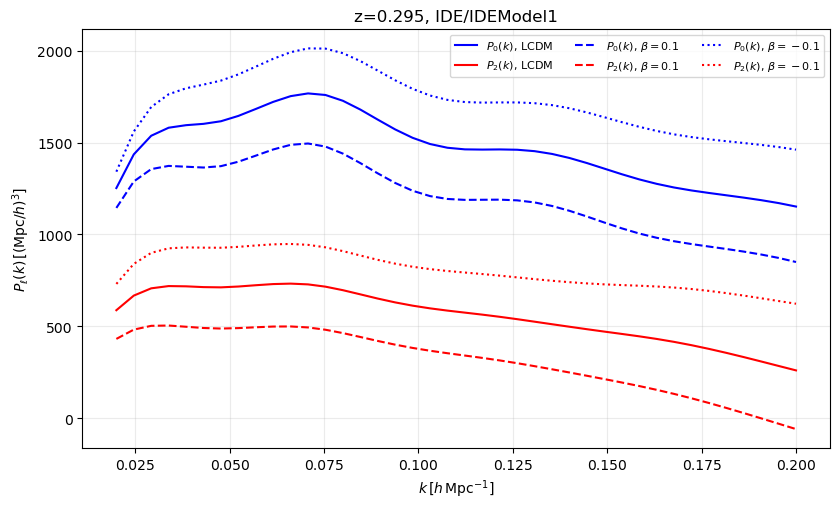

In [1]:
#!/usr/bin/env python3
import os
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '/global/homes/n/nishavk/FOLPSpipe/')
sys.path.insert(0, '/global/homes/n/nishavk/fkptjax_muMG/src/')
sys.path.insert(0, '/global/homes/n/nishavk/isitIDE/')
sys.path.insert(0, '/global/homes/n/nishavk/desilike/')
sys.path.insert(0, '/global/homes/n/nishavk/cosmoprimo/')

# -----------------------------
# Optional JAX settings (debug)
# -----------------------------
os.environ.setdefault("JAX_DISABLE_JIT", "1")  # set "0" for speed once validated
import jax
jax.config.update("jax_enable_x64", True)

# -----------------------------
# desilike / cosmoprimo imports
# -----------------------------
from desilike.theories import Cosmoprimo
from desilike.theories.galaxy_clustering import DirectPowerSpectrumTemplate
from desilike.theories.galaxy_clustering import fkptjaxTracerPowerSpectrumMultipoles
from desilike import parameter
from cosmoprimo.fiducial import DESI

# ============================================================
# USER SETTINGS
# ============================================================
z_eff = 0.295
k = np.linspace(0.02, 0.20, 40)
ells = (0, 2)

IDE_model = "IDE"
ide_variant = "IDEModel1"
beyond_eds = True     # set False for EdS kernels
rescale_PS = False

# Two beta values to compare
beta_a = 0.0
beta_b = 0.1

# ---- nuisance params (STANDARD basis names) ----
freedom = "max"
prior_basis = "standard"   # alias -> standard_folps
tracer_tag = "BGS"
b3_coev = True
shotnoise_opt = 1e4

b1 = 1.70
b2 = -0.45
bs2 = 0.0
b3nl = 0.0
alpha0, alpha2, alpha4 = 3.0, -29.0, 0.0
ctilde = 0.0
alpha0shot, alpha2shot = 0.08, -8.0

# ---- cosmology ----
h = 0.6711
ombh2 = 0.022
omch2 = 0.122
As = 2e-9
ns = 0.965
Neff = 3.046
mnu = 0.06  # eV


# ============================================================
# Define cosmology class (isitIDE via Cosmoprimo)
# ============================================================

# ----- (A) beta = 0.0 -----
cosmo = Cosmoprimo(engine="isitide", dark_energy_model=ide_variant, N_eff=Neff, m_ncdm=[mnu])
beta = 0.0

cosmo.init.params["h"].update(value=h)
cosmo.init.params["omega_b"].update(value=ombh2)
cosmo.init.params["omega_cdm"].update(value=omch2)
cosmo.init.params["logA"].update(value=float(np.log(1e10 * As)))
cosmo.init.params["n_s"].update(value=ns)

# ensure beta exists (depends on build); add if missing
if "beta" not in cosmo.init.params:
    cosmo.init.params.data.append(parameter.Parameter(basename="beta", value=0.0, fixed=True))
cosmo.init.params["beta"].update(value=float(beta), fixed=True)

# ============================================================
# Defining template (DirectPowerSpectrumTemplate)
# ============================================================
template = DirectPowerSpectrumTemplate(z=float(z_eff), fiducial=DESI(), cosmo=cosmo)
template.init.update(with_now="peakaverage")  # required by fkptjax path (needs pknow_dd)


# ============================================================
# Calling fkptjax tracer (beta=0.0)
# ============================================================
theory_results = fkptjaxTracerPowerSpectrumMultipoles()
theory_results.init.update(
    freedom=freedom,
    prior_basis=prior_basis,
    tracer=tracer_tag,
    template=template,
    k=np.array(k, dtype=float),
    ells=list(ells),
    model=IDE_model,
    ide_variant=ide_variant,
    b3_coev=bool(b3_coev),
    beyond_eds=bool(beyond_eds),
    rescale_PS=bool(rescale_PS),
    shotnoise=float(shotnoise_opt),
)

# fix nuisance params (standard basis names)
for name, val in dict(
    b1=b1, b2=b2, bs2=bs2, b3nl=b3nl,
    alpha0=alpha0, alpha2=alpha2, alpha4=alpha4,
    ctilde=ctilde, alpha0shot=alpha0shot, alpha2shot=alpha2shot
).items():
    if name in theory_results.init.params:
        theory_results.init.params[name].update(fixed=True, value=float(val))

Pell_LCDM = theory_results()  # evaluate

# unpack multipoles for beta=0.0
Pell_LCDM = np.asarray(Pell_LCDM)
P0_LCDM = Pell_LCDM[0]
P2_LCDM = Pell_LCDM[1]

# ----- (B) beta = 0.1 -----
Pell_beta_pos = theory_results(beta=0.1)  # evaluate

# unpack multipoles for beta=0.1
Pell_beta_pos = np.asarray(Pell_beta_pos)
P0_beta_pos = Pell_beta_pos[0]
P2_beta_pos = Pell_beta_pos[1]

# ----- (B) beta = -0.1 -----
Pell_beta_neg = theory_results(beta=-0.1)  # evaluate

# unpack multipoles for beta=-0.1
Pell_beta_neg = np.asarray(Pell_beta_neg)
P0_beta_neg = Pell_beta_neg[0]
P2_beta_neg = Pell_beta_neg[1]

# ============================================================
# Plot: monopole + quadrupole, both mu0 values on one figure
# ============================================================
plt.figure(figsize=(8.5, 5.2))

plt.plot(k, k*P0_LCDM, color='b', label=r"$P_0(k)$, LCDM")
plt.plot(k, k*P2_LCDM, color='r', label=r"$P_2(k)$, LCDM")

plt.plot(k, k*P0_beta_pos, color='b', ls="--", label=r"$P_0(k)$, $\beta=0.1$")
plt.plot(k, k*P2_beta_pos, color='r', ls="--", label=r"$P_2(k)$, $\beta=0.1$")

plt.plot(k, k*P0_beta_neg, color='b', ls="dotted", label=r"$P_0(k)$, $\beta=-0.1$")
plt.plot(k, k*P2_beta_neg, color='r', ls="dotted", label=r"$P_2(k)$, $\beta=-0.1$")

plt.xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P_\ell(k)\,[(\mathrm{Mpc}/h)^3]$")
plt.title(fr"z={z_eff}, {IDE_model}/{ide_variant}")
plt.grid(alpha=0.25)
plt.legend(ncols=3, fontsize=8)
plt.tight_layout()
plt.savefig('IDE_multipoles.png', dpi=300)
plt.show()

# Testing EdS vs Beyond-EdS corrections

/global/homes/n/nishavk/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/global/homes/n/nishavk/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))


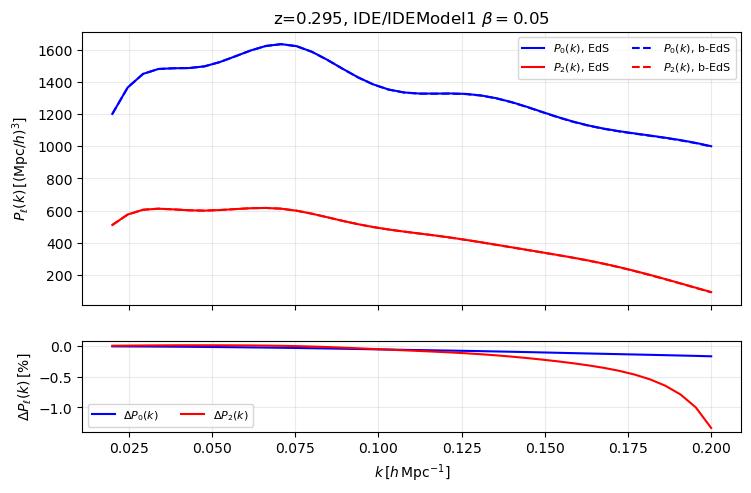

In [2]:
# ============================================================
# Calling fkptjax tracer (beta=0.0)
# ============================================================
theory_results_EdS = fkptjaxTracerPowerSpectrumMultipoles()
theory_results_EdS.init.update(
    freedom=freedom,
    prior_basis=prior_basis,
    tracer=tracer_tag,
    template=template,
    k=np.array(k, dtype=float),
    ells=list(ells),
    model=IDE_model,
    ide_variant=ide_variant,
    b3_coev=bool(b3_coev),
    beyond_eds=False,
    rescale_PS=bool(rescale_PS),
    shotnoise=float(shotnoise_opt),
)

# fix nuisance params (standard basis names)
for name, val in dict(
    b1=b1, b2=b2, bs2=bs2, b3nl=b3nl,
    alpha0=alpha0, alpha2=alpha2, alpha4=alpha4,
    ctilde=ctilde, alpha0shot=alpha0shot, alpha2shot=alpha2shot
).items():
    if name in theory_results_EdS.init.params:
        theory_results_EdS.init.params[name].update(fixed=True, value=float(val))

beta = 0.05

# ----- (B) beta = 0.1 -----
Pell_EdS = theory_results_EdS(beta=beta)  # evaluate

# unpack multipoles for beta=0.1
Pell_EdS = np.asarray(Pell_EdS)
P0_EdS = Pell_EdS[0]
P2_EdS = Pell_EdS[1]

theory_results_beyondEdS = fkptjaxTracerPowerSpectrumMultipoles()
theory_results_beyondEdS.init.update(
    freedom=freedom,
    prior_basis=prior_basis,
    tracer=tracer_tag,
    template=template,
    k=np.array(k, dtype=float),
    ells=list(ells),
    model=IDE_model,
    ide_variant=ide_variant,
    b3_coev=bool(b3_coev),
    beyond_eds=True,
    rescale_PS=bool(rescale_PS),
    shotnoise=float(shotnoise_opt),
)

# fix nuisance params (standard basis names)
for name, val in dict(
    b1=b1, b2=b2, bs2=bs2, b3nl=b3nl,
    alpha0=alpha0, alpha2=alpha2, alpha4=alpha4,
    ctilde=ctilde, alpha0shot=alpha0shot, alpha2shot=alpha2shot
).items():
    if name in theory_results_beyondEdS.init.params:
        theory_results_beyondEdS.init.params[name].update(fixed=True, value=float(val))

# ----- (B) beta = 0.1 -----
Pell_beyondEdS = theory_results_beyondEdS(beta=beta)  # evaluate

# unpack multipoles for beta=0.1
Pell_beyondEdS = np.asarray(Pell_beyondEdS)
P0_beyondEdS = Pell_beyondEdS[0]
P2_beyondEdS = Pell_beyondEdS[1]

diff_P0 = (P0_beyondEdS - P0_EdS)*100 / P0_EdS
diff_P2 = (P2_beyondEdS - P2_EdS)*100 / P2_EdS

# ============================================================
# Plot: monopole + quadrupole, both mu0 values on one figure
# ============================================================
fig, axs = plt.subplots(2, 1, figsize=(8.5, 5.2), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

axs[0].plot(k, k*P0_EdS, color='b', label=r"$P_0(k)$, EdS")
axs[0].plot(k, k*P2_EdS, color='r', label=r"$P_2(k)$, EdS")

axs[0].plot(k, k*P0_beyondEdS, color='b', ls="--", label=r"$P_0(k)$, b-EdS")
axs[0].plot(k, k*P2_beyondEdS, color='r', ls="--", label=r"$P_2(k)$, b-EdS")

# axs[0].set_xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
axs[0].set_ylabel(r"$P_\ell(k)\,[(\mathrm{Mpc}/h)^3]$")
axs[0].set_title(fr"z={z_eff}, {IDE_model}/{ide_variant} $\beta={beta}$")
axs[0].grid(alpha=0.25)
axs[0].legend(ncols=2, fontsize=8)

axs[1].plot(k, diff_P0, color='b', label=r"$\Delta P_0(k)$")
axs[1].plot(k, diff_P2, color='r', label=r"$\Delta P_2(k)$")

axs[1].set_xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
axs[1].set_ylabel(r"$\Delta P_\ell(k)\,[ \%]$")
axs[1].grid(alpha=0.25)
axs[1].legend(ncols=2, fontsize=8)

plt.savefig('IDE_multipoles_EdS_vs_bEdS.png', dpi=300)
plt.show()